In [8]:
import pandas as pd
import pathlib
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)

In [2]:
path = '/home/exafs/exafs/fit/cucd4l/output/cucd_2021.5_1.dat'
df = pd.read_csv(path, sep='\s+', skiprows=7, header=None)
path = '/home/exafs/exafs/fit/cucd4l/output/cucd_2021.5_1_ks.dat'
dfk = pd.read_csv(path, sep='\s+', skiprows=8, header=None)

<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_126582/3358339867.py:2: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(path, sep='\s+', skiprows=7, header=None)
/tmp/ipykernel_126582/3358339867.py:4: SyntaxWarning: invalid escape sequence '\s'
  dfk = pd.read_csv(path, sep='\s+', skiprows=8, header=None)


In [36]:
plt.rcParams['text.usetex'] = False
fontsize=12

def read_dat(
    path
):
    df_list = []
    if not (isinstance(path, list) or isinstance(path, tuple)):
        path = [path]
    for p in path:
        p = pathlib.Path(p)
        with p.open() as f:
            line_list = []
            i = 0
            for line in f:
                if line.startswith('#'):
                    i += 1
                    line_list.append(line)
            df = pd.read_csv(p, skiprows=i, sep=r'\s+', engine='python', header=None)
        df_list.append(df)
    return df_list

def plot_R(
    df,
    dim=(3.25,3.25),
    plot_fit=False,
    savefig=None,
    fontsize=12
    ):
    fig, ax = plt.subplots(layout='constrained')
    # df.plot(x=0, y=3, ax=ax)
    ax.errorbar(df[0], df[1], yerr=df[2], fmt='-', color='gray')
    ax.errorbar(df[0], df[3], yerr=df[4], fmt='-', color='black')
    
    if plot_fit:
        ax.plot(df[0], df[5], color='#4298B5', zorder=999)
        ax.plot(df[0], df[6], color='#4298B5', zorder=998)
    # df.plot(x=0, y=1, ax=ax)
    # ax.plot(df[0], np.sqrt(df[1]**2+df[6]**2))
    ax.set_xlim(0,6)
    ax.set_xlabel('$R$ (Å)', fontsize=fontsize)
    ax.set_ylabel(r"$|\chi(R)|$"+" or "+r"Re[$\chi(R)$]", fontsize=fontsize)

    ax.xaxis.set_major_locator(MultipleLocator(2))
    ax.xaxis.set_minor_locator(MultipleLocator(0.5))    

    ax.tick_params(labelsize=fontsize)
    
    # ax.legend(
    #     # handles=[r"$|\chi(R)|$", r"Re[$\chi(R)$]"], 
    #     # loc=legend_loc,
    #     frameon=False, 
    #     fontsize=fontsize, 
    #     labelspacing=0.075/2, 
    #     borderpad=0, 
    #     handlelength=1, 
    #     handletextpad=0.2
    # )
    
    fig.set_size_inches(*dim)
    if savefig:
        fig.savefig(savefig)
    
def plot_k(
    df,
    dim=(3.25,3.25),
    plot_fit=False,
    savefig=None,
    xlim=(2.5,16)
    ):
    fig, ax = plt.subplots(layout='constrained')
    # df.plot(x=0, y=3, ax=ax)
    ax.plot(df[5], df[6], color='black')
    
    if plot_fit:
        ax.plot(df[0], df[3], color='#4298B5', zorder=999)
    
    # ax.errorbar(df[5], df[6], yerr=df[7], fmt='-', color='black')
    # ax.errorbar(df[0], df[3], yerr=df[4], fmt='+', color='black')
    # df.plot(x=0, y=1, ax=ax)
    # ax.plot(df[0], np.sqrt(df[1]**2+df[6]**2))
    ax.set_xlim(*xlim)
    ax.set_xlabel('$k$ (Å$^{-1}$)', fontsize=fontsize)
    ax.set_ylabel(r"$\chi(k)k^3$", fontsize=fontsize)
    
    ax.xaxis.set_major_locator(MultipleLocator(2))
    ax.xaxis.set_minor_locator(MultipleLocator(1))
    
    ax.tick_params(labelsize=fontsize)
    fig.set_size_inches(*dim)
    if savefig:
        fig.savefig(savefig)

In [32]:
path = '/home/exafs/exafs/fit/cucd4l/output/cucd_2021.5_1.dat'
read_dat(path)

[         0        1        2        3        4        5        6        7   \
 0     0.000 -0.27403  0.05106  0.27403  0.05106 -0.01534  0.02272  0.00000   
 1     0.025 -0.27231  0.04162  0.27315  0.04154 -0.20549  0.22491  0.02140   
 2     0.050 -0.26784  0.01846  0.27087  0.01911 -0.21182  0.23990  0.04038   
 3     0.075 -0.26283  0.00586  0.26851  0.00869 -0.21571  0.25465  0.05495   
 4     0.100 -0.26111  0.01838  0.26896  0.01806 -0.21815  0.27093  0.06452   
 ..      ...      ...      ...      ...      ...      ...      ...      ...   
 795  19.875 -0.00870  0.09549  0.12900  0.09257  0.00000  0.00000  0.12871   
 796  19.900  0.07560  0.02212  0.12158  0.11405  0.00000  0.00000  0.09522   
 797  19.925  0.11494  0.07520  0.11577  0.07655  0.00000  0.00000  0.01384   
 798  19.950  0.08720  0.15702  0.11373  0.12985  0.00000  0.00000 -0.07301   
 799  19.975  0.00462  0.18523  0.11730  0.03373  0.00000  0.00000 -0.11721   
 
           8        9   ...       13       14     

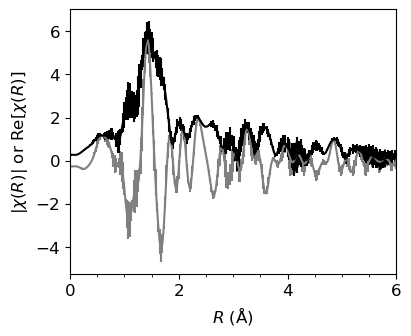

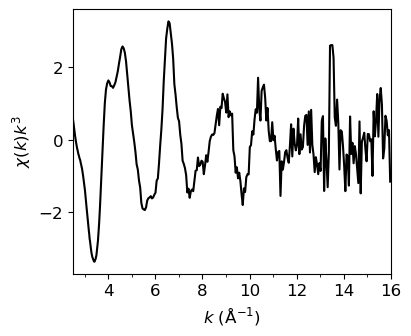

In [4]:
dim=(4,3.25)
plot_R(df, dim=dim, savefig='he_cucd4l_R_16.svg')
plot_k(dfk, dim=dim, savefig='he_cucd4l_k_16.svg')

<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_126582/1078543161.py:2: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(path, sep='\s+', skiprows=7, header=None)
/tmp/ipykernel_126582/1078543161.py:4: SyntaxWarning: invalid escape sequence '\s'
  dfk = pd.read_csv(path, sep='\s+', skiprows=8, header=None)


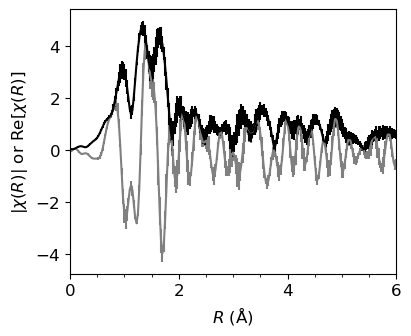

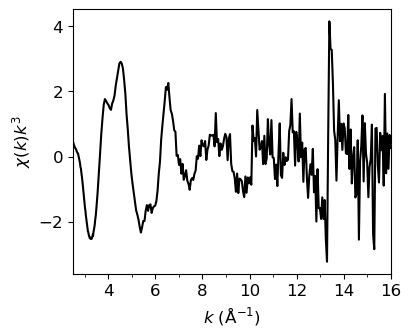

In [5]:
path = '/home/exafs/exafs/fit/cucd4l/output/co_cucd_widek.1_1.dat'
df = pd.read_csv(path, sep='\s+', skiprows=7, header=None)
path = '/home/exafs/exafs/fit/cucd4l/output/co_cucd_widek.1_1_ks.dat'
dfk = pd.read_csv(path, sep='\s+', skiprows=8, header=None)
dim=(4,3.25)
plot_R(df, dim=dim, savefig='co_cucd4l_R_16.svg')
plot_k(dfk, dim=dim, savefig='co_cucd4l_k_16.svg')

<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_126582/3416328818.py:2: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(path, sep='\s+', skiprows=7, header=None)
/tmp/ipykernel_126582/3416328818.py:4: SyntaxWarning: invalid escape sequence '\s'
  dfk = pd.read_csv(path, sep='\s+', skiprows=8, header=None)


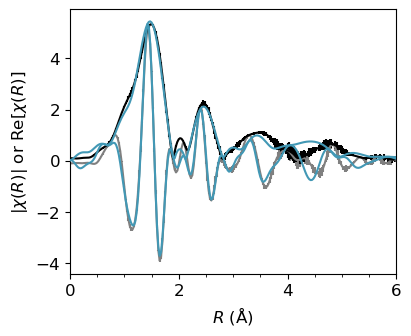

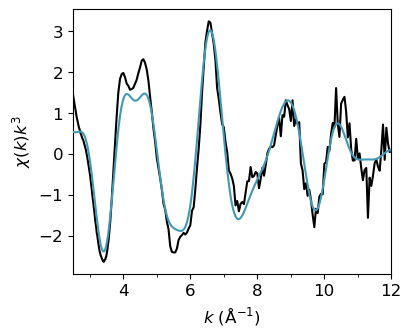

In [6]:
path = '/home/exafs/exafs/fit/cucd4l/output/cucd2021.2_1.dat'
df = pd.read_csv(path, sep='\s+', skiprows=7, header=None)
path = '/home/exafs/exafs/fit/cucd4l/output/cucd2021.2_1_ks.dat'
dfk = pd.read_csv(path, sep='\s+', skiprows=8, header=None)
dim=(4,3.25)
plot_R(df, dim=dim, savefig='he_cucd4l_R_12.svg', plot_fit=True)
plot_k(dfk, dim=dim, savefig='he_cucd4l_k_12.svg', plot_fit=True, xlim=(2.5,12))

<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_126582/280112280.py:2: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(path, sep='\s+', skiprows=7, header=None)
/tmp/ipykernel_126582/280112280.py:4: SyntaxWarning: invalid escape sequence '\s'
  dfk = pd.read_csv(path, sep='\s+', skiprows=8, header=None)


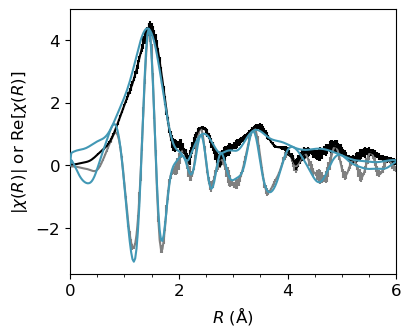

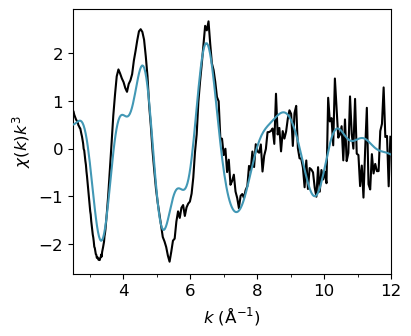

In [7]:
path = '/home/exafs/exafs/fit/cucd4l/output/co_cucd252627.1_1.dat'
df = pd.read_csv(path, sep='\s+', skiprows=7, header=None)
path = '/home/exafs/exafs/fit/cucd4l/output/co_cucd252627.1_1_ks.dat'
dfk = pd.read_csv(path, sep='\s+', skiprows=8, header=None)
dim=(4,3.25)
plot_R(df, dim=dim, savefig='co_cucd4l_R_12.svg', plot_fit=True)
plot_k(dfk, dim=dim, savefig='co_cucd4l_k_12.svg', plot_fit=True, xlim=(2.5,12))

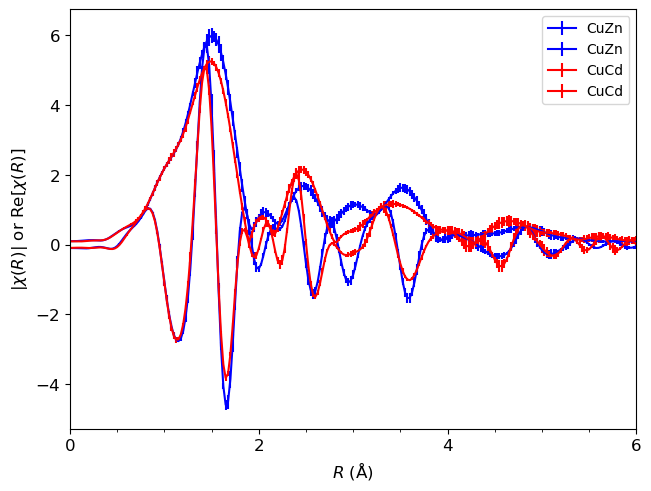

In [40]:
stem = '/home/exafs/exafs/fit/'
path = [
    'cuzn4l/output/he_cuzn4l.70_1.dat',
    'cucd4l/output/he_cucd.47_1.dat'
]
path = [stem+p for p in path]
df_list = read_dat(path)
fig, ax = plt.subplots(layout='constrained')
fontsize=12
color = ['blue', 'red']
i = 0
for df in df_list:
    # plot_R(df, dim=dim, savefig=False)
    ax.errorbar(df[0], df[1], yerr=df[2], fmt='-', color=color[i])
    ax.errorbar(df[0], df[3], yerr=df[4], fmt='-', color=color[i])
    
    # if plot_fit:
    #     ax.plot(df[0], df[5], color='#4298B5', zorder=999)
    #     ax.plot(df[0], df[6], color='#4298B5', zorder=998)
    # df.plot(x=0, y=1, ax=ax)
    # ax.plot(df[0], np.sqrt(df[1]**2+df[6]**2))
    
    i+=1
ax.set_xlim(0,6)
ax.set_xlabel('$R$ (Å)', fontsize=fontsize)
ax.set_ylabel(r"$|\chi(R)|$"+" or "+r"Re[$\chi(R)$]", fontsize=fontsize)

ax.xaxis.set_major_locator(MultipleLocator(2))
ax.xaxis.set_minor_locator(MultipleLocator(0.5))    

ax.tick_params(labelsize=fontsize)

ax.legend(['CuZn', 'CuZn', 'CuCd', 'CuCd'])

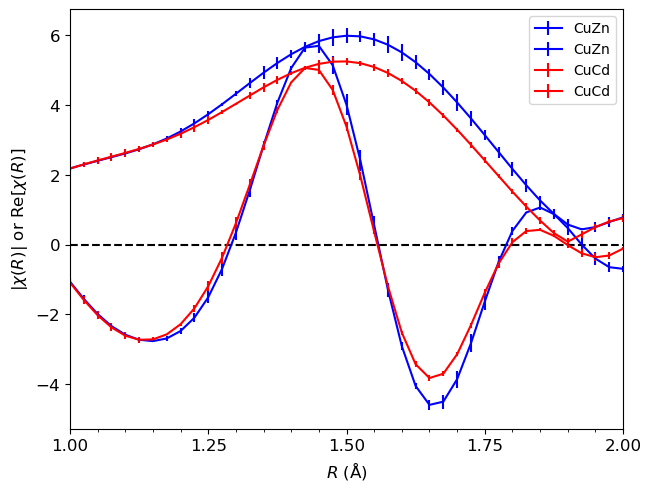

In [47]:
stem = '/home/exafs/exafs/fit/'
path = [
    'cuzn4l/output/he_cuzn4l.70_1.dat',
    'cucd4l/output/he_cucd.47_1.dat'
]
path = [stem+p for p in path]
df_list = read_dat(path)
fig, ax = plt.subplots(layout='constrained')
fontsize=12
color = ['blue', 'red']
i = 0
for df in df_list:
    # plot_R(df, dim=dim, savefig=False)
    ax.errorbar(df[0], df[1], yerr=df[2], fmt='-', color=color[i])
    ax.errorbar(df[0], df[3], yerr=df[4], fmt='-', color=color[i])
    
    # if plot_fit:
    #     ax.plot(df[0], df[5], color='#4298B5', zorder=999)
    #     ax.plot(df[0], df[6], color='#4298B5', zorder=998)
    # df.plot(x=0, y=1, ax=ax)
    # ax.plot(df[0], np.sqrt(df[1]**2+df[6]**2))
    
    i+=1
ax.set_xlim(1,2)
ax.set_xlabel('$R$ (Å)', fontsize=fontsize)
ax.set_ylabel(r"$|\chi(R)|$"+" or "+r"Re[$\chi(R)$]", fontsize=fontsize)

ax.xaxis.set_major_locator(MultipleLocator(0.25))
ax.xaxis.set_minor_locator(MultipleLocator(0.05))    

ax.tick_params(labelsize=fontsize)

ax.legend(['CuZn', 'CuZn', 'CuCd', 'CuCd'])

ax.hlines(0, 1, 2, color='black', linestyle='--')
